# 09 - Health Score Generation

**Project:** GroundedNutriRec  
**Scope:** Generate a composite Health Score for each recipe using normalized nutritional features (protein, calories, fat) and ingredient diversity.  

## Objectives:
1. Load recipe data from `RAW_recipes.csv` (archive_3 dataset).
2. Parse the `nutrition` field to extract calories, total fat, and protein values.
3. Parse the `ingredients` field to compute ingredient diversity (count of unique ingredients).
4. Normalize protein, calorie, fat, and ingredient-diversity features using Min-Max scaling.
5. Compute a composite **Health Score** by combining the normalized features with domain-informed weights.
6. Analyze the distribution of the Health Score across recipes.
7. Save the enriched recipe dataset with Health Scores for downstream use.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
import warnings

warnings.filterwarnings('ignore')

# Configure plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Paths
recipes_path = Path("dataset/archive_3/RAW_recipes.csv")
output_path = Path("dataset/archive_3/recipes_with_health_score.csv")

print(f"Source data: {recipes_path}")
print(f"Output destination: {output_path}")
print("Setup complete.")

Source data: dataset\archive_3\RAW_recipes.csv
Output destination: dataset\archive_3\recipes_with_health_score.csv
Setup complete.


## 2. Load Dataset

In [2]:
print("Loading RAW_recipes.csv...")
df = pd.read_csv(recipes_path)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:")
print(df.isnull().sum())
df.head()

Loading RAW_recipes.csv...


Dataset shape: (231637, 12)
Columns: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']

Missing values:
name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


## 3. Parse Nutrition Field

The `nutrition` column in `RAW_recipes.csv` is stored as a string representation of a list:  
`[calories, total_fat (% DV), sugar (% DV), sodium (% DV), protein (% DV), saturated_fat (% DV), carbohydrates (% DV)]`

We will extract:
- **Calories** (index 0) — absolute kcal
- **Total Fat** (index 1) — % daily value
- **Protein** (index 4) — % daily value

In [3]:
print("Parsing nutrition field...")

# Vectorized extraction using str.strip and str.split (much faster than ast.literal_eval)
nutrition_clean = df['nutrition'].str.strip('[]')
nutrition_split = nutrition_clean.str.split(',', expand=True).astype(float)

# Assign columns: [calories, total_fat, sugar, sodium, protein, saturated_fat, carbohydrates]
df['calories'] = nutrition_split[0]
df['total_fat_pdv'] = nutrition_split[1]
df['sugar_pdv'] = nutrition_split[2]
df['sodium_pdv'] = nutrition_split[3]
df['protein_pdv'] = nutrition_split[4]
df['saturated_fat_pdv'] = nutrition_split[5]
df['carbohydrates_pdv'] = nutrition_split[6]

print(f"\nNutrition features extracted. Sample:")
df[['name', 'calories', 'total_fat_pdv', 'protein_pdv']].head(10)

Parsing nutrition field...



Nutrition features extracted. Sample:


,name,calories,total_fat_pdv,protein_pdv
0,arriba baked winter squash mexican style,51.5,0.0,2.0
1,a bit different breakfast pizza,173.4,18.0,22.0
2,all in the kitchen chili,269.8,22.0,39.0
3,alouette potatoes,368.1,17.0,14.0
4,amish tomato ketchup for canning,352.9,1.0,3.0
5,apple a day milk shake,160.2,10.0,9.0
6,aww marinated olives,380.7,53.0,6.0
7,backyard style barbecued ribs,1109.5,83.0,96.0
8,bananas 4 ice cream pie,4270.8,254.0,127.0
9,beat this banana bread,2669.3,160.0,62.0


## 4. Compute Ingredient Diversity

Ingredient diversity is measured as the number of unique ingredients in each recipe (`n_ingredients` column). Recipes with a wider variety of ingredients tend to offer more diverse nutritional profiles.

In [4]:
# Use the existing n_ingredients column directly (avoids slow ast.literal_eval parsing)
df['ingredient_diversity'] = df['n_ingredients'].copy()

print("Ingredient diversity statistics:")
print(df['ingredient_diversity'].describe())

df[['name', 'n_ingredients', 'ingredient_diversity']].head(10)

Ingredient diversity statistics:
count    231637.000000
mean          9.051153
std           3.734796
min           1.000000
25%           6.000000
50%           9.000000
75%          11.000000
max          43.000000
Name: ingredient_diversity, dtype: float64


,name,n_ingredients,ingredient_diversity
0,arriba baked winter squash mexican style,7,7
1,a bit different breakfast pizza,6,6
2,all in the kitchen chili,13,13
3,alouette potatoes,11,11
4,amish tomato ketchup for canning,8,8
5,apple a day milk shake,4,4
6,aww marinated olives,9,9
7,backyard style barbecued ribs,22,22
8,bananas 4 ice cream pie,6,6
9,beat this banana bread,9,9


## 5. Exploratory Analysis of Nutritional Features

Before normalization, let's understand the distributions and identify outliers in our target features.

NUTRITIONAL FEATURE STATISTICS (Raw)
            calories  total_fat_pdv   protein_pdv  ingredient_diversity
count  231637.000000   231637.00000  231637.00000         231637.000000
mean      473.942425       36.08070      34.68186              9.051153
std      1189.711374       77.79884      58.47248              3.734796
min         0.000000        0.00000       0.00000              1.000000
25%       174.400000        8.00000       7.00000              6.000000
50%       313.400000       20.00000      18.00000              9.000000
75%       519.700000       41.00000      51.00000             11.000000
max    434360.200000    17183.00000    6552.00000             43.000000


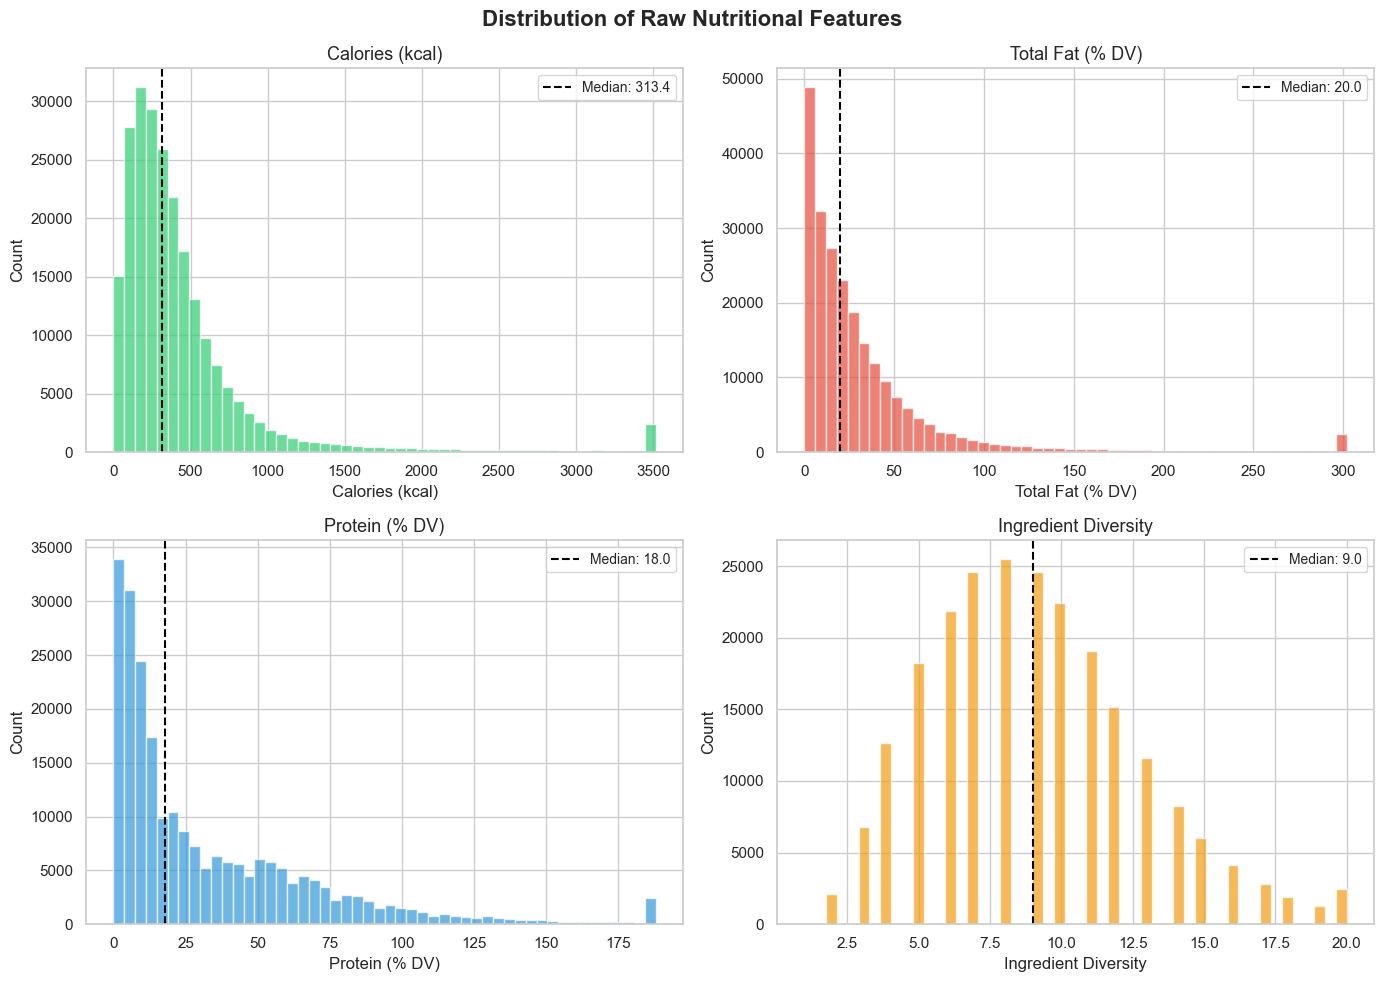

In [5]:
features = ['calories', 'total_fat_pdv', 'protein_pdv', 'ingredient_diversity']

print("=" * 60)
print("NUTRITIONAL FEATURE STATISTICS (Raw)")
print("=" * 60)
print(df[features].describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Raw Nutritional Features', fontsize=16, fontweight='bold')

colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
titles = ['Calories (kcal)', 'Total Fat (% DV)', 'Protein (% DV)', 'Ingredient Diversity']

for i, (feature, color, title) in enumerate(zip(features, colors, titles)):
    ax = axes[i // 2][i % 2]
    data = df[feature].dropna()
    
    # Clip for visualization (extreme outliers can distort histograms)
    clip_upper = data.quantile(0.99)
    data_clipped = data.clip(upper=clip_upper)
    
    ax.hist(data_clipped, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 6. Outlier Capping

Nutritional data can have extreme outliers (e.g., recipes with absurdly high calories). We cap at the 99th percentile to prevent outliers from dominating the normalization.

In [6]:
print("Capping outliers at 99th percentile...\n")

for feature in features:
    q99 = df[feature].quantile(0.99)
    q01 = df[feature].quantile(0.01)
    
    outliers_above = (df[feature] > q99).sum()
    outliers_below = (df[feature] < q01).sum()
    
    print(f"{feature}:")
    print(f"  99th percentile: {q99:.2f}")
    print(f"  1st percentile:  {q01:.2f}")
    print(f"  Values capped above: {outliers_above}")
    print(f"  Values capped below: {outliers_below}")
    
    df[f'{feature}_capped'] = df[feature].clip(lower=q01, upper=q99)

print("\nCapped feature statistics:")
capped_features = [f'{f}_capped' for f in features]
print(df[capped_features].describe())

Capping outliers at 99th percentile...

calories:
  99th percentile: 3516.96
  1st percentile:  18.40
  Values capped above: 2317
  Values capped below: 2314
total_fat_pdv:
  99th percentile: 302.00
  1st percentile:  0.00
  Values capped above: 2314
  Values capped below: 0
protein_pdv:
  99th percentile: 188.00
  1st percentile:  0.00
  Values capped above: 2295
  Values capped below: 0
ingredient_diversity:
  99th percentile: 20.00
  1st percentile:  3.00
  Values capped above: 1639
  Values capped below: 2152

Capped feature statistics:
       calories_capped  total_fat_pdv_capped  protein_pdv_capped  \
count    231637.000000         231637.000000       231637.000000   
mean        449.898333             33.913231           33.273000   
std         519.333576             46.563242           37.159058   
min          18.400000              0.000000            0.000000   
25%         174.400000              8.000000            7.000000   
50%         313.400000             20.000000 

## 7. Min-Max Normalization

Normalize all features to [0, 1] range using Min-Max scaling:  
$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$

In [7]:
print("Applying Min-Max normalization...\n")

normalized_features = []
for feature in features:
    capped_col = f'{feature}_capped'
    norm_col = f'{feature}_norm'
    
    x_min = df[capped_col].min()
    x_max = df[capped_col].max()
    
    if x_max - x_min == 0:
        df[norm_col] = 0.0
    else:
        df[norm_col] = (df[capped_col] - x_min) / (x_max - x_min)
    
    normalized_features.append(norm_col)
    print(f"{feature}: min={x_min:.2f}, max={x_max:.2f} -> normalized to [0, 1]")

print("\nNormalized feature statistics:")
print(df[normalized_features].describe())

df[['name'] + normalized_features].head(10)

Applying Min-Max normalization...

calories: min=18.40, max=3516.96 -> normalized to [0, 1]
total_fat_pdv: min=0.00, max=302.00 -> normalized to [0, 1]
protein_pdv: min=0.00, max=188.00 -> normalized to [0, 1]
ingredient_diversity: min=3.00, max=20.00 -> normalized to [0, 1]

Normalized feature statistics:
       calories_norm  total_fat_pdv_norm  protein_pdv_norm  \
count  231637.000000       231637.000000     231637.000000   
mean        0.123336            0.112295          0.176984   
std         0.148442            0.154183          0.197655   
min         0.000000            0.000000          0.000000   
25%         0.044590            0.026490          0.037234   
50%         0.084321            0.066225          0.095745   
75%         0.143288            0.135762          0.271277   
max         1.000000            1.000000          1.000000   

       ingredient_diversity_norm  
count              231637.000000  
mean                    0.355192  
std                     0.21

,name,calories_norm,total_fat_pdv_norm,protein_pdv_norm,ingredient_diversity_norm
0,arriba baked winter squash mexican style,0.009461,0.000000,0.010638,0.235294
1,a bit different breakfast pizza,0.044304,0.059603,0.117021,0.176471
2,all in the kitchen chili,0.071858,0.072848,0.207447,0.588235
3,alouette potatoes,0.099956,0.056291,0.074468,0.470588
4,amish tomato ketchup for canning,0.095611,0.003311,0.015957,0.294118
5,apple a day milk shake,0.040531,0.033113,0.047872,0.058824
6,aww marinated olives,0.103557,0.175497,0.031915,0.352941
7,backyard style barbecued ribs,0.311872,0.274834,0.510638,1.000000
8,bananas 4 ice cream pie,1.000000,0.841060,0.675532,0.176471
9,beat this banana bread,0.757713,0.529801,0.329787,0.352941


## 8. Normalized Feature Distributions

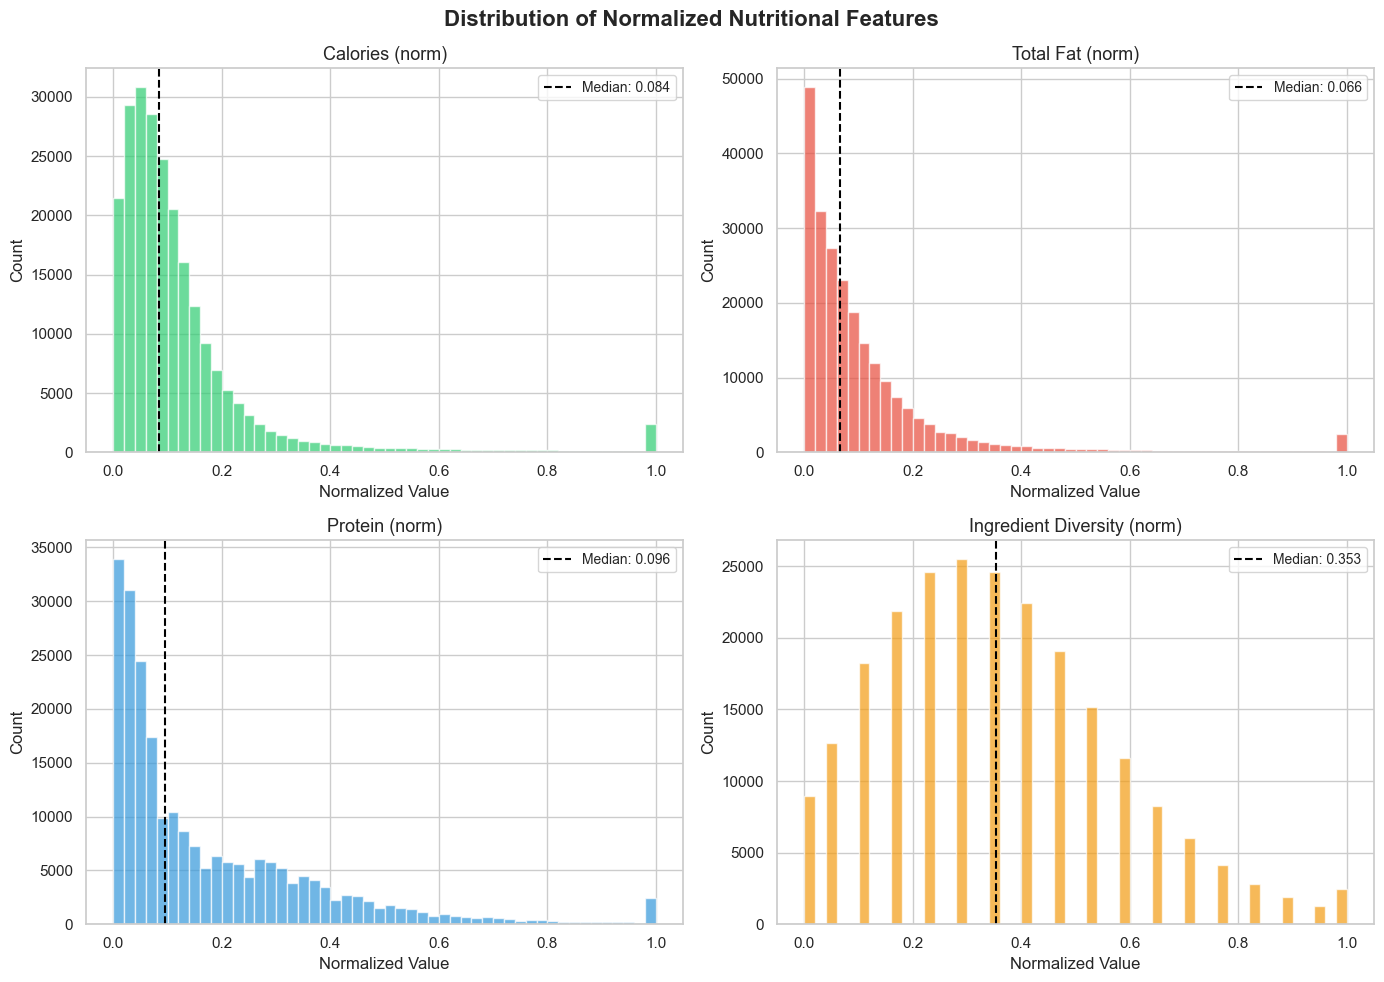

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Normalized Nutritional Features', fontsize=16, fontweight='bold')

norm_names = ['Calories (norm)', 'Total Fat (norm)', 'Protein (norm)', 'Ingredient Diversity (norm)']
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

for i, (col, name, color) in enumerate(zip(normalized_features, norm_names, colors)):
    ax = axes[i // 2][i % 2]
    data = df[col].dropna()
    ax.hist(data, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('Normalized Value')
    ax.set_ylabel('Count')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.3f}')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 9. Feature Correlation Analysis

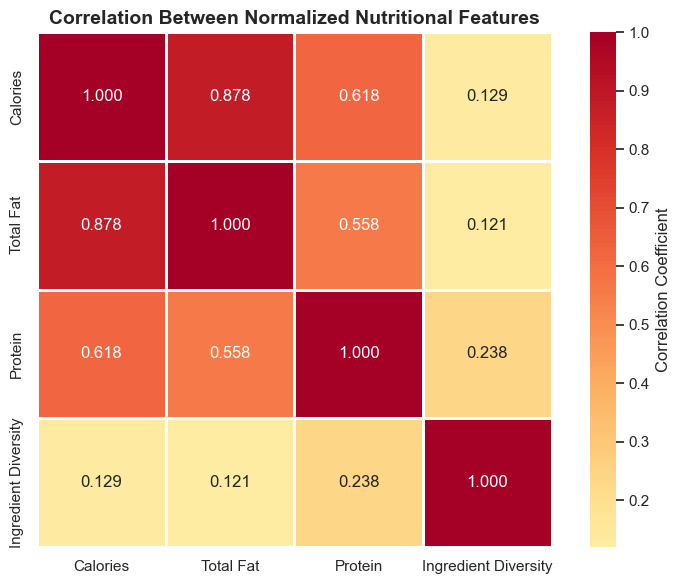

Correlation matrix:
                      Calories  Total Fat   Protein  Ingredient Diversity
Calories              1.000000   0.877977  0.618421              0.128989
Total Fat             0.877977   1.000000  0.558303              0.120803
Protein               0.618421   0.558303  1.000000              0.237991
Ingredient Diversity  0.128989   0.120803  0.237991              1.000000


In [9]:
corr_df = df[normalized_features].rename(columns={
    'calories_norm': 'Calories',
    'total_fat_pdv_norm': 'Total Fat',
    'protein_pdv_norm': 'Protein',
    'ingredient_diversity_norm': 'Ingredient Diversity'
})

corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.3f', linewidths=1, square=True,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Between Normalized Nutritional Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation matrix:")
print(corr_matrix)

## 10. Health Score Computation

The Health Score is a weighted composite of the normalized features. The scoring logic is:

- **Higher protein** -> healthier (positive contribution)
- **Lower calories** -> healthier (inverted: 1 - normalized_calories)
- **Lower fat** -> healthier (inverted: 1 - normalized_fat)
- **Higher ingredient diversity** -> healthier (positive contribution, as diverse ingredients correlate with balanced nutrition)

### Weight Assignment:
| Feature | Weight | Rationale |
|---------|--------|-----------|
| Protein (norm) | 0.30 | High protein is a key health indicator |
| 1 - Calories (norm) | 0.30 | Lower calorie density promotes health |
| 1 - Fat (norm) | 0.25 | Lower fat content is generally healthier |
| Ingredient Diversity (norm) | 0.15 | Diverse ingredients support nutritional balance |

$$\text{Health Score} = 0.30 \times \text{protein}_{norm} + 0.30 \times (1 - \text{calories}_{norm}) + 0.25 \times (1 - \text{fat}_{norm}) + 0.15 \times \text{diversity}_{norm}$$

In [10]:
# Define weights
W_PROTEIN = 0.30
W_CALORIES = 0.30
W_FAT = 0.25
W_DIVERSITY = 0.15

print("Computing Health Score...")
print(f"\nWeights:")
print(f"  Protein (positive):              {W_PROTEIN}")
print(f"  Calories (inverted):             {W_CALORIES}")
print(f"  Fat (inverted):                  {W_FAT}")
print(f"  Ingredient Diversity (positive): {W_DIVERSITY}")
print(f"  Total:                           {W_PROTEIN + W_CALORIES + W_FAT + W_DIVERSITY}")

# Compute Health Score
df['health_score'] = (
    W_PROTEIN * df['protein_pdv_norm'] +
    W_CALORIES * (1 - df['calories_norm']) +
    W_FAT * (1 - df['total_fat_pdv_norm']) +
    W_DIVERSITY * df['ingredient_diversity_norm']
)

# Handle NaN values (recipes with missing nutrition data)
nan_count = df['health_score'].isna().sum()
print(f"\nRecipes with NaN Health Score (missing nutrition data): {nan_count}")

print(f"\nHealth Score statistics:")
print(df['health_score'].describe())

df[['name', 'calories', 'total_fat_pdv', 'protein_pdv', 'ingredient_diversity', 'health_score']].head(15)

Computing Health Score...

Weights:
  Protein (positive):              0.3
  Calories (inverted):             0.3
  Fat (inverted):                  0.25
  Ingredient Diversity (positive): 0.15
  Total:                           1.0

Recipes with NaN Health Score (missing nutrition data): 0

Health Score statistics:
count    231637.000000
mean          0.591299
std           0.073811
min           0.000000
25%           0.560706
50%           0.591582
75%           0.630485
max           0.898592
Name: health_score, dtype: float64


,name,calories,total_fat_pdv,protein_pdv,ingredient_diversity,health_score
0,arriba baked winter squash mexican style,51.5,0.0,2.0,7,0.585647
1,a bit different breakfast pizza,173.4,18.0,22.0,6,0.583385
2,all in the kitchen chili,269.8,22.0,39.0,13,0.660700
3,alouette potatoes,368.1,17.0,14.0,11,0.598869
4,amish tomato ketchup for canning,352.9,1.0,3.0,8,0.569394
5,apple a day milk shake,160.2,10.0,9.0,4,0.552748
6,aww marinated olives,380.7,53.0,6.0,9,0.537574
7,backyard style barbecued ribs,1109.5,83.0,96.0,22,0.690921
8,bananas 4 ice cream pie,4270.8,254.0,127.0,6,0.268865
9,beat this banana bread,2669.3,160.0,62.0,9,0.342113


## 11. Health Score Distribution Analysis

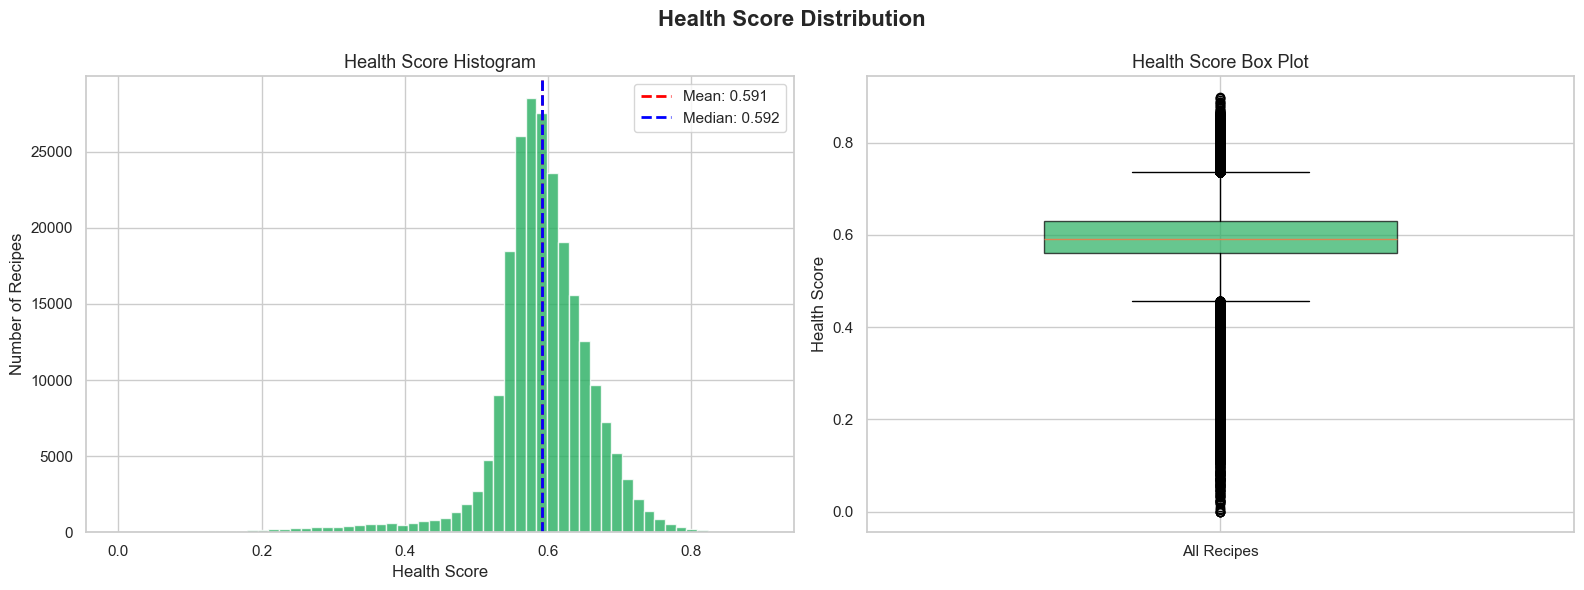

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Health Score Distribution', fontsize=16, fontweight='bold')

# Histogram
ax1 = axes[0]
health_scores = df['health_score'].dropna()
ax1.hist(health_scores, bins=60, color='#27ae60', alpha=0.8, edgecolor='white')
ax1.axvline(health_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {health_scores.mean():.3f}')
ax1.axvline(health_scores.median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {health_scores.median():.3f}')
ax1.set_title('Health Score Histogram', fontsize=13)
ax1.set_xlabel('Health Score')
ax1.set_ylabel('Number of Recipes')
ax1.legend(fontsize=11)

# Box plot
ax2 = axes[1]
bp = ax2.boxplot(health_scores, vert=True, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#27ae60')
bp['boxes'][0].set_alpha(0.7)
ax2.set_title('Health Score Box Plot', fontsize=13)
ax2.set_ylabel('Health Score')
ax2.set_xticklabels(['All Recipes'])

plt.tight_layout()
plt.show()

## 12. Top and Bottom Recipes by Health Score

In [12]:
display_cols = ['name', 'calories', 'total_fat_pdv', 'protein_pdv', 
                'ingredient_diversity', 'health_score']

print("=" * 70)
print("TOP 15 HEALTHIEST RECIPES (Highest Health Score)")
print("=" * 70)
top_healthy = df.nlargest(15, 'health_score')[display_cols].reset_index(drop=True)
display(top_healthy)

print("\n" + "=" * 70)
print("BOTTOM 15 LEAST HEALTHY RECIPES (Lowest Health Score)")
print("=" * 70)
bottom_healthy = df.nsmallest(15, 'health_score')[display_cols].reset_index(drop=True)
display(bottom_healthy)

TOP 15 HEALTHIEST RECIPES (Highest Health Score)


,name,calories,total_fat_pdv,protein_pdv,ingredient_diversity,health_score
0,party size barbecued albacore tuna with shri...,702.3,41.0,195.0,19,0.898592
1,glens bouillabaisse fish soup,554.7,18.0,161.0,20,0.896027
2,bayou turtle soup,644.4,11.0,162.0,22,0.895725
3,cioppino seafood stew,789.8,39.0,203.0,19,0.892744
4,garam masala curried chicken with pineapple an...,831.9,51.0,217.0,20,0.888024
5,lomo saltado vegan,980.3,15.0,192.0,18,0.887453
6,pork tenderloin thai style,622.2,32.0,176.0,18,0.884938
7,chicken curry with whole spices,756.2,42.0,217.0,18,0.884319
8,chicken dhansak,887.3,53.0,202.0,25,0.881618
9,crabmeat cheesecake with pecan crust creole,842.8,61.0,189.0,20,0.878811



BOTTOM 15 LEAST HEALTHY RECIPES (Lowest Health Score)


,name,calories,total_fat_pdv,protein_pdv,ingredient_diversity,health_score
0,chive flower oil,7708.5,1341.0,0.0,2,0.000000
1,homemade failsafe margarine,3590.5,670.0,0.0,3,0.000000
2,lecithin pan coating,7167.1,1341.0,0.0,2,0.000000
3,olive oil with herbs,12135.5,2111.0,0.0,2,0.000000
4,basil oil,4055.1,704.0,2.0,2,0.003191
5,parsnip chips,3946.8,665.0,4.0,3,0.006383
6,homemade hand soap,4926.0,840.0,0.0,4,0.008824
7,delicious deep fried artichokes,3930.4,671.0,10.0,3,0.015957
8,crispy shallots ina garten back to basics,6483.2,1103.0,11.0,3,0.017553
9,decorators icing,5365.3,315.0,0.0,5,0.017647


## 13. Health Score by Ingredient Count Bins

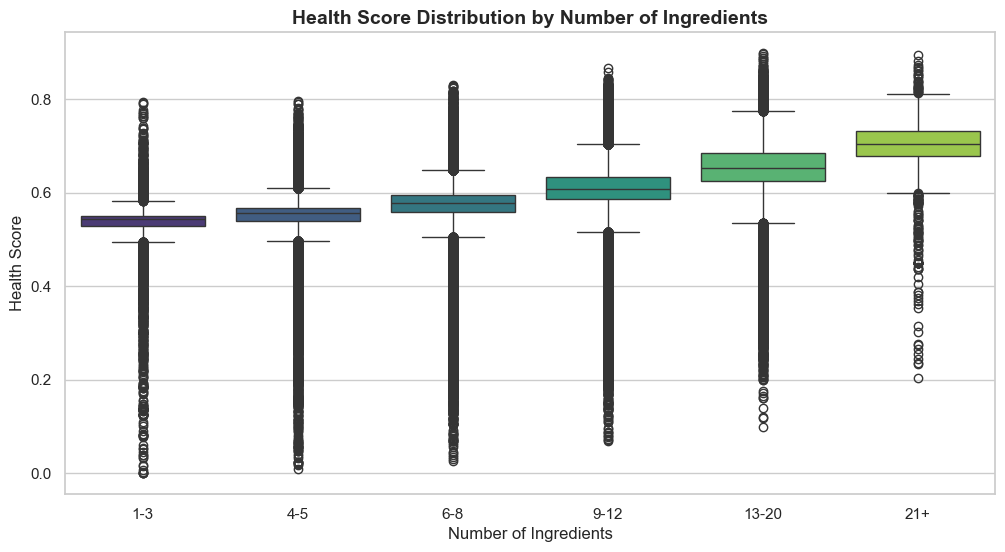

Mean Health Score by Ingredient Count:
                    mean    median  count
ingredient_bin                           
1-3             0.530609  0.543546   8952
4-5             0.547150  0.555993  30867
6-8             0.572107  0.577248  71971
9-12            0.603884  0.607572  81288
13-20           0.647998  0.652548  36920
21+             0.695651  0.703669   1639


In [13]:
# Create ingredient count bins
bins = [0, 3, 5, 8, 12, 20, 50]
labels = ['1-3', '4-5', '6-8', '9-12', '13-20', '21+']
df['ingredient_bin'] = pd.cut(df['ingredient_diversity'], bins=bins, labels=labels, right=True)

# Box plot of Health Score by ingredient bins
plt.figure(figsize=(12, 6))
ingredient_order = ['1-3', '4-5', '6-8', '9-12', '13-20', '21+']
sns.boxplot(data=df.dropna(subset=['health_score', 'ingredient_bin']), 
            x='ingredient_bin', y='health_score', order=ingredient_order,
            palette='viridis')
plt.title('Health Score Distribution by Number of Ingredients', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ingredients', fontsize=12)
plt.ylabel('Health Score', fontsize=12)
plt.show()

# Summary statistics by bin
print("Mean Health Score by Ingredient Count:")
print(df.groupby('ingredient_bin', observed=False)['health_score'].agg(['mean', 'median', 'count']).to_string())

## 14. Health Score vs Individual Nutritional Features

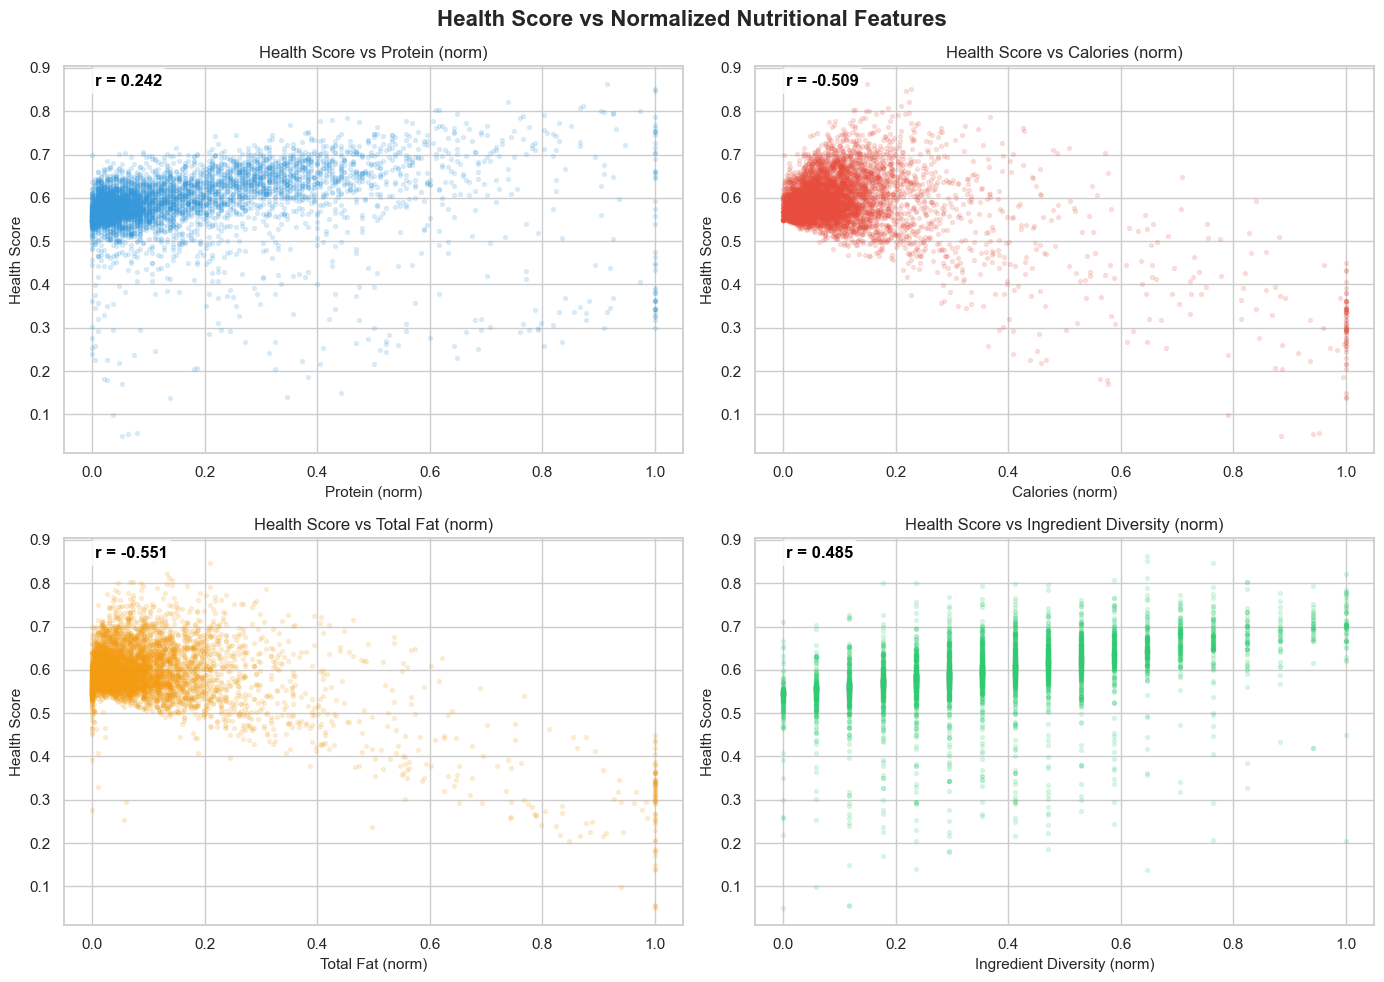

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Health Score vs Normalized Nutritional Features', fontsize=16, fontweight='bold')

scatter_features = [
    ('protein_pdv_norm', 'Protein (norm)', '#3498db'),
    ('calories_norm', 'Calories (norm)', '#e74c3c'),
    ('total_fat_pdv_norm', 'Total Fat (norm)', '#f39c12'),
    ('ingredient_diversity_norm', 'Ingredient Diversity (norm)', '#2ecc71')
]

# Sample for scatter plot (to avoid overplotting)
sample_df = df.dropna(subset=['health_score']).sample(n=min(5000, len(df)), random_state=42)

for i, (col, label, color) in enumerate(scatter_features):
    ax = axes[i // 2][i % 2]
    ax.scatter(sample_df[col], sample_df['health_score'], 
              alpha=0.15, s=8, color=color)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Health Score', fontsize=11)
    ax.set_title(f'Health Score vs {label}', fontsize=12)
    
    # Add correlation annotation
    corr = df[col].corr(df['health_score'])
    ax.annotate(f'r = {corr:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=12, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## 15. Health Score Percentile Categorization

Quantile thresholds: Q80=0.6415, Q60=0.6049, Q40=0.5793, Q20=0.5535

Health Category Distribution:
health_category
Very Healthy    46328
Unhealthy       46328
Moderate        46327
Less Healthy    46327
Healthy         46327
Name: count, dtype: int64


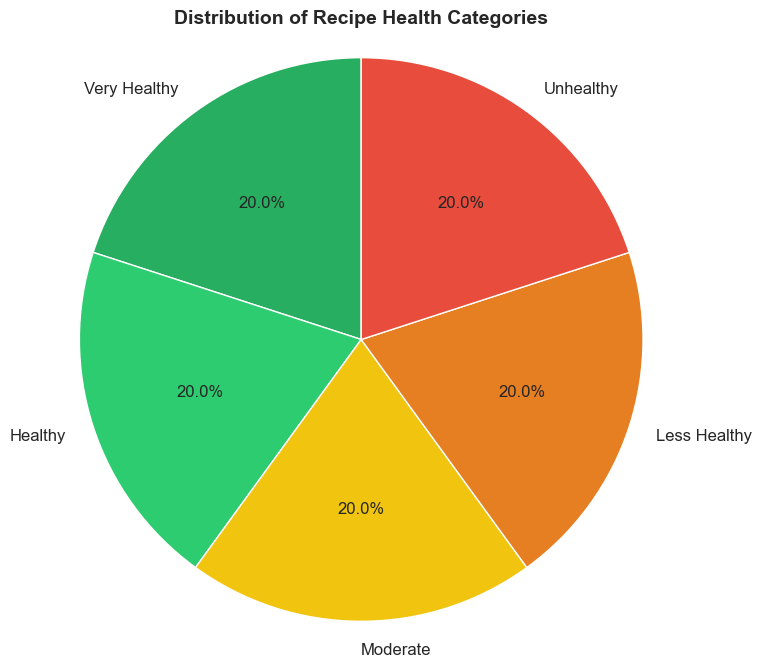

In [15]:
# Pre-compute quantile thresholds ONCE (vectorized approach)
q80 = df['health_score'].quantile(0.80)
q60 = df['health_score'].quantile(0.60)
q40 = df['health_score'].quantile(0.40)
q20 = df['health_score'].quantile(0.20)

print(f'Quantile thresholds: Q80={q80:.4f}, Q60={q60:.4f}, Q40={q40:.4f}, Q20={q20:.4f}')

# Vectorized categorization using np.select (fast)
conditions = [
    df['health_score'].isna(),
    df['health_score'] >= q80,
    df['health_score'] >= q60,
    df['health_score'] >= q40,
    df['health_score'] >= q20,
]
choices = ['Unknown', 'Very Healthy', 'Healthy', 'Moderate', 'Less Healthy']
df['health_category'] = np.select(conditions, choices, default='Unhealthy')

# Distribution of categories
category_counts = df['health_category'].value_counts()
print('\nHealth Category Distribution:')
print(category_counts)

# Pie chart
plt.figure(figsize=(8, 8))
category_order = ['Very Healthy', 'Healthy', 'Moderate', 'Less Healthy', 'Unhealthy']
category_colors = ['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

counts = [category_counts.get(cat, 0) for cat in category_order]
plt.pie(counts, labels=category_order, colors=category_colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
plt.title('Distribution of Recipe Health Categories', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

## 16. Component Contribution Analysis

Visualize how each feature component contributes to the final Health Score.

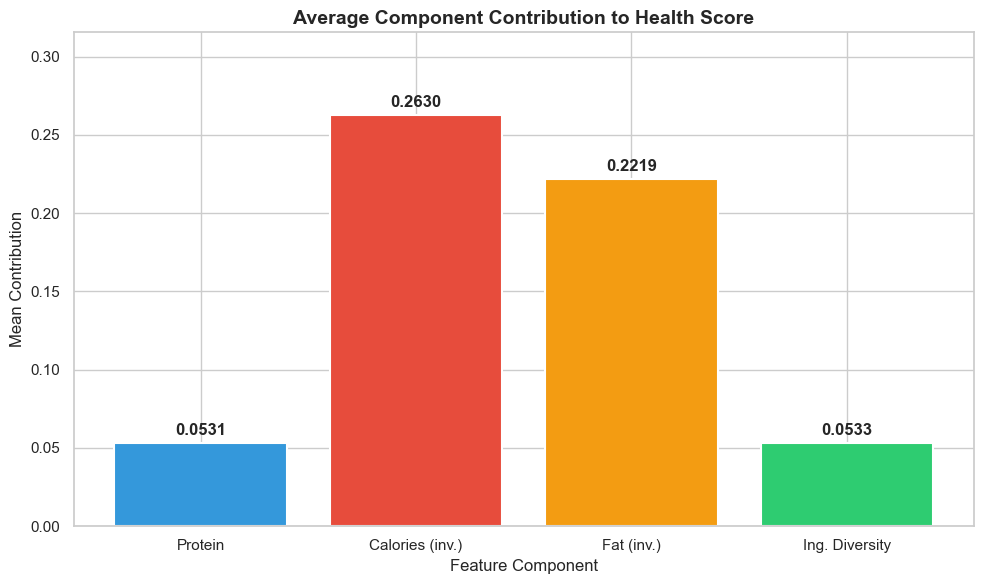


Mean Component Contributions:
  Protein                  : 0.0531 (9.0%)
  Calories (inv.)          : 0.2630 (44.5%)
  Fat (inv.)               : 0.2219 (37.5%)
  Ing. Diversity           : 0.0533 (9.0%)


In [16]:
# Compute individual contributions
df['contribution_protein'] = W_PROTEIN * df['protein_pdv_norm']
df['contribution_calories'] = W_CALORIES * (1 - df['calories_norm'])
df['contribution_fat'] = W_FAT * (1 - df['total_fat_pdv_norm'])
df['contribution_diversity'] = W_DIVERSITY * df['ingredient_diversity_norm']

contribution_cols = ['contribution_protein', 'contribution_calories', 
                     'contribution_fat', 'contribution_diversity']

# Mean contributions
mean_contributions = df[contribution_cols].mean()
mean_contributions.index = ['Protein', 'Calories (inv.)', 'Fat (inv.)', 'Ing. Diversity']

plt.figure(figsize=(10, 6))
bars = plt.bar(mean_contributions.index, mean_contributions.values, 
               color=['#3498db', '#e74c3c', '#f39c12', '#2ecc71'],
               edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, mean_contributions.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Average Component Contribution to Health Score', fontsize=14, fontweight='bold')
plt.ylabel('Mean Contribution', fontsize=12)
plt.xlabel('Feature Component', fontsize=12)
plt.ylim(0, max(mean_contributions.values) * 1.2)
plt.tight_layout()
plt.show()

print("\nMean Component Contributions:")
for name, val in mean_contributions.items():
    pct = (val / mean_contributions.sum()) * 100
    print(f"  {name:25s}: {val:.4f} ({pct:.1f}%)")

## 17. Save Enriched Dataset

In [17]:
# Select columns to save
save_columns = [
    'name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
    'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients',
    'calories', 'total_fat_pdv', 'protein_pdv',
    'ingredient_diversity',
    'calories_norm', 'total_fat_pdv_norm', 'protein_pdv_norm', 'ingredient_diversity_norm',
    'health_score', 'health_category'
]

df_save = df[save_columns].copy()

print(f"Saving enriched dataset with Health Scores...")
print(f"Output path: {output_path}")
print(f"Shape: {df_save.shape}")
print(f"Columns: {df_save.columns.tolist()}")

df_save.to_csv(output_path, index=False)

print(f"\nSaved successfully!")
print(f"File size: {output_path.stat().st_size / (1024*1024):.2f} MB")

Saving enriched dataset with Health Scores...
Output path: dataset\archive_3\recipes_with_health_score.csv
Shape: (231637, 22)
Columns: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients', 'calories', 'total_fat_pdv', 'protein_pdv', 'ingredient_diversity', 'calories_norm', 'total_fat_pdv_norm', 'protein_pdv_norm', 'ingredient_diversity_norm', 'health_score', 'health_category']



Saved successfully!
File size: 308.21 MB


## 18. Summary

### Key Findings:

| Metric | Value |
|--------|-------|
| Total recipes processed | See output above |
| Features used | Normalized protein, calories, fat, ingredient diversity |
| Normalization | Min-Max with 99th percentile capping |
| Health Score range | [0, 1] |
| Health Score formula | 0.30 x protein + 0.30 x (1-calories) + 0.25 x (1-fat) + 0.15 x diversity |

### Design Decisions:
1. **Outlier capping** at 99th/1st percentile prevents extreme values from dominating normalization.
2. **Calories and fat are inverted** (1 - normalized value) because lower values indicate healthier recipes.
3. **Protein gets the highest weight** along with calories - these are the most impactful nutritional indicators.
4. **Ingredient diversity** gets a lower weight as it is a softer proxy for nutritional balance.
5. The Health Score output can be directly integrated into the recommendation pipeline as a re-ranking or filtering signal.

### Output:
- Enriched dataset saved to `dataset/archive_3/recipes_with_health_score.csv` with all original recipe fields plus:
  - Parsed nutritional features
  - Normalized features
  - Composite Health Score
  - Health Category (Very Healthy / Healthy / Moderate / Less Healthy / Unhealthy)